# ETFs: model-based features

The features built in `03_financial_features` are arithmetic on past bars: a 21-day return is
the same function of the same twenty-two prices whoever computes it. The features built here
are not. Each one is the output of a statistical model whose parameters were themselves
estimated from bars, so the stretch of history the model was fitted on becomes part of what
the feature knows. This notebook fits three such models and writes what they infer.

- A **hidden Markov model** on the broad US equity market, which infers whether each session
  is a calm one or a stressed one.
- **Fractional differencing** of ten reference ETF price series, a filter that removes enough
  of a price's trend to make it statistically stable while keeping some of its long memory.
- A **GARCH(1,1)** volatility model per ETF, which infers how volatile each asset is on each
  session given how it has moved so far.

Each model is estimated on a **refit schedule** rather than once per cross-validation fold: it
spends a burn-in, fits on everything up to that point, speaks for the sessions that follow
until the next refit, and so on to the end of the history. The output is therefore one value
per ETF per session - the same value whichever fold a later notebook reads it under.

## Learning objectives

By the end of this notebook you will be able to:

- Explain why a feature computed from a fitted model can read the future even when the
  formula behind it only looks backwards, and name the two channels that happens through.
- Estimate a model on a refit schedule, so that the parameters behind every emitted value
  were fitted on observations that end before it.
- Say what the burn-in costs: the sessions at the start of the history that carry no value
  because nothing had been fitted yet, and how to report them rather than hide them.
- Run a hidden Markov model forward through a series so that the state it reports for a given
  session depends only on that session and the ones before it, rather than on the whole
  series at once.
- Difference a price series by a fractional amount, and check with a statistical test whether
  the result is stable enough to use as a model input.
- Freeze a model's parameters at the holdout boundary, so that a value inside the holdout is
  computed from data inside it but from coefficients estimated entirely before it.
- Check that a feature value does not move when later observations are deleted, which is the
  property all of the above exists to produce.

## Book reference

Chapter 9, on fractional differencing, volatility models and regime features. Chapter 9 states
the requirement this whole stage exists to satisfy: an estimate must be generated using only
information available at the time of decision, re-estimated within the walk-forward protocol,
and versioned alongside the features it produces.

## Prerequisites

- [`02_labels`](02_labels.ipynb) writes the forward-return files. This notebook reads the
  primary one at the end, to measure whether the features it built rank anything.
- [`03_financial_features`](03_financial_features.ipynb) writes the arithmetic features.
  Chapter 11 joins that table to the one written here; neither reads the other.

In [1]:
"""ETFs: model-based features from a walk-forward HMM, fractional differencing and GARCH."""

import multiprocessing
import os
import warnings
from concurrent.futures import ProcessPoolExecutor

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from arch import arch_model
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr, robust_ic
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.engineer.features.fdiff import ffdiff
from statsmodels.tsa.stattools import adfuller

from case_studies.utils.artifact_digest import value_digest
from case_studies.utils.cv_window import (
    configured_labels,
    modeling_fold_boundaries,
)
from case_studies.utils.temporal import (
    filtered_state_probs,
    fit_hmm_kmeans_init,
    garch11_conditional_volatility,
    refit_boundaries,
    sort_states_by_variance,
    walk_forward_feature,
    write_model_based,
)
from data import load_etfs
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.modeling import resolve_label_buffer, resolve_label_horizon
from utils.paths import REPO_ROOT, display_path, get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
# Production defaults. Papermill overrides these for the reduced continuous-integration run.
CASE_STUDY_ID = "etfs"
SEED = 42
MAX_SYMBOLS = 0
# The estimation schedule lives in `config/setup.yaml`, because an estimation window is part of
# a fitted feature's definition. Zero here means "use what the configuration declares", which is
# what a production run does; a reduced run overrides one of these rather than editing the
# case study's configuration, and the cell below prints which value it ended up with.
HMM_RESTARTS = 0
HMM_BURNIN = 0
HMM_REFIT_EVERY = 0
GARCH_BURNIN = 0
GARCH_REFIT_EVERY = 0

## Configuration

Everything below that decides an estimation window, a boundary or a horizon is read from the
case study's `setup.yaml` rather than typed here, so that changing the configuration changes
what this notebook computes.

In [3]:
set_global_seeds(SEED)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
LABEL_HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
LABEL_HORIZON_DAYS = int(str(LABEL_HORIZON).rstrip("Dd"))

# The HMM reads a realized-volatility series alongside returns. It uses the shortest window the
# case study declares for volatility, so the regime model and the stage-03 volatility features
# describe the same span of market history.
VOL_WINDOW = min(SETUP["features"]["windows"]["volatility"])

# The largest basket the strategy ever holds. A rank correlation computed across fewer names
# than that is not measuring an ordering the strategy could act on, so those sessions are
# dropped from the evaluation at the end.
MIN_CROSS_SECTION = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])

# The serial-dependence correction on the coefficient series uses lags out to the label horizon,
# so the series needs to be several times that long before the correction means anything.
MIN_IC_SESSIONS = 3 * LABEL_HORIZON_DAYS

_SCHEDULE = SETUP["model_based"]
STATE_COUNT = int(_SCHEDULE["hmm"]["n_states"])
N_RESTARTS = int(HMM_RESTARTS or _SCHEDULE["hmm"]["n_restarts"])
HMM_BURNIN_SESSIONS = int(HMM_BURNIN or _SCHEDULE["hmm"]["burnin"])
HMM_REFIT_SESSIONS = int(HMM_REFIT_EVERY or _SCHEDULE["hmm"]["refit_every"])
GARCH_BURNIN_SESSIONS = int(GARCH_BURNIN or _SCHEDULE["garch"]["burnin"])
GARCH_REFIT_SESSIONS = int(GARCH_REFIT_EVERY or _SCHEDULE["garch"]["refit_every"])

EVAL_CONFIG = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = str(EVAL_CONFIG["holdout_start"])
HOLDOUT_END = str(EVAL_CONFIG["holdout_end"])

print(
    f"Target: {PRIMARY_LABEL}, a return realized {LABEL_HORIZON_DAYS} trading sessions after the "
    "session it is attached to."
)
print(
    f"Regime model reads {VOL_WINDOW}-session realized volatility, the shortest volatility "
    "window this case study declares."
)
print(
    f"Sessions before {HOLDOUT_START} are available for development; {HOLDOUT_START} to "
    f"{HOLDOUT_END} is the holdout and is read once, in the final notebook of the case study."
)
print(
    f"A validation session needs at least {MIN_CROSS_SECTION} ETFs quoting to be scored - the "
    f"largest basket the strategy holds - and at least {MIN_IC_SESSIONS} such sessions before "
    "the coefficient across them is corrected for serial dependence."
)
print(
    f"Regime model: {HMM_BURNIN_SESSIONS} sessions of burn-in, then refitted every "
    f"{HMM_REFIT_SESSIONS} from {N_RESTARTS} starting points, on the market series."
)
print(
    f"Volatility model: {GARCH_BURNIN_SESSIONS} sessions of burn-in per ETF, then refitted "
    f"every {GARCH_REFIT_SESSIONS}."
)

Target: fwd_ret_21d, a return realized 21 trading sessions after the session it is attached to.
Regime model reads 21-session realized volatility, the shortest volatility window this case study declares.
Sessions before 2024-01-01 are available for development; 2024-01-01 to 2025-12-31 is the holdout and is read once, in the final notebook of the case study.
A validation session needs at least 20 ETFs quoting to be scored - the largest basket the strategy holds - and at least 63 such sessions before the coefficient across them is corrected for serial dependence.
Regime model: 756 sessions of burn-in, then refitted every 63 from 10 starting points, on the market series.
Volatility model: 504 sessions of burn-in per ETF, then refitted every 21.


## A. Why a fitted feature is different

A financial feature is a function of past bars. Compute a 21-session return on Tuesday and you
get the same number you would have got on Tuesday, because the arithmetic reaches back and
never forward.

A model-based feature is a function of *parameters estimated from* bars, and that adds a
second channel through which the future can reach a value that looks backward-facing. Two
things have to hold, not one:

**The parameters must come from the past of the value they produce.** Fit a volatility model
once over the whole history and its coefficients have read every crash in the sample. Apply
them to 2008 and the 2008 volatility they produce is partly a memory of 2020. Nothing in the
formula looks forward; the coefficients did the looking.

Fitting inside a cross-validation fold is not the fix, and this notebook used to make that
mistake. A fold model is estimated on the fold's whole training window and then run forward
**from the start of that same window**, so a training row near the beginning of it carries
parameters estimated from years of its own future while every validation row carries
parameters estimated only from its past. The model is then fitted on one version of the column
and scored on another. Nothing raises: a fold's own rows agree with each other, and the
artifact records no estimation window at all.

The fix is a **refit schedule**. Spend a burn-in, fit on everything up to that point, let those
parameters speak for the sessions that follow until the next refit, then refit on everything up
to *that* point and carry on. No observation is ever used to estimate the parameters that
describe it, at any position in the history. Two costs come with it and both are stated below:
the burn-in carries no value at all, and the parameters change under the reader as the series
advances, which is what section D measures.

**The inference must also come from the past.** This one is easier to miss, because it
outlives a correct fit. Given fixed parameters, most of these models can be run two ways over
a series. The *filtered* pass reports, for each session, what the model concludes from that
session and the ones before it. The *smoothed* pass reports what the model concludes from the
entire series, so its answer for 2008 is revised once it has seen 2020. Both are legitimate
statistics and the smoothed one is usually the more accurate description of what happened.
Only the filtered one is available to someone standing in 2008, so only the filtered one can
be a feature.

Both channels reduce to one testable property, and section E tests it rather than describing
it: **deleting the observations after a session must not move that session's value.**

### The data these models run on

Before fitting anything, look at the panel. The universe is a hundred exchange-traded funds
assembled to cover the asset classes a diversified investor can reach through them, and the
download configuration that defines it groups them into nine categories. The table below is
that grouping, with the history each category actually has on disk.

Two things in it decide what happens further down. The panel is **unbalanced**: several of
these funds launched well after the sample begins, so the number quoting on a session grows
through the history. A fund also has to pay the volatility model's burn-in out of its own
history, so the late arrivals carry no conditional volatility for their first two years. And
the categories are **not equally sized**: a cross-sectional ranking over this universe is
dominated by equities, because more than half the names are equity funds of one kind or
another.

In [4]:
prices = load_etfs()

_universe_cfg = yaml.safe_load(
    (REPO_ROOT / "data" / "etfs" / "market" / "config.yaml").read_text()
)["etfs"]["tickers"]
category_of = {sym: name for name, block in _universe_cfg.items() for sym in block["symbols"]}

universe = (
    prices.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("first_session"),
        pl.col("timestamp").max().alias("last_session"),
        pl.len().alias("sessions"),
    )
    .with_columns(category=pl.col("symbol").replace_strict(category_of, default="uncategorised"))
)
assert not universe.filter(pl.col("category") == "uncategorised").height, (
    "an ETF in the price panel is missing from the universe configuration"
)

display(
    universe.group_by("category")
    .agg(
        pl.len().alias("ETFs"),
        pl.col("first_session").min().alias("earliest start"),
        pl.col("first_session").max().alias("latest start"),
        pl.col("sessions").min().alias("shortest history"),
    )
    .sort("ETFs", descending=True)
)

sessions_per_date = prices.group_by("timestamp").agg(pl.len().alias("n_quoting")).sort("timestamp")
print(
    f"{universe.height} ETFs, {prices.height:,} rows, "
    f"{prices['timestamp'].n_unique():,} sessions from {prices['timestamp'].min()} to "
    f"{prices['timestamp'].max()}."
)
print(
    f"Quoting on the first session: {sessions_per_date['n_quoting'][0]}. "
    f"On the last: {sessions_per_date['n_quoting'][-1]}."
)
print(
    f"ETFs with fewer than {GARCH_BURNIN_SESSIONS} sessions in the whole panel, which can "
    "therefore carry no conditional volatility at all: "
    f"{universe.filter(pl.col('sessions') <= GARCH_BURNIN_SESSIONS).height}."
)

category,ETFs,earliest start,latest start,shortest history
str,u32,date,date,u32
"""international_developed""",18,2006-01-03,2012-10-24,3315
"""fixed_income""",15,2006-01-03,2013-06-04,3165
"""us_sectors""",13,2006-01-03,2018-06-19,1895
"""emerging_markets""",11,2006-01-03,2012-10-24,3315
"""specialty""",10,2006-01-03,2006-06-22,4913
"""us_equity_broad""",10,2006-01-03,2006-01-03,5031
"""us_equity_style""",10,2006-01-03,2013-07-18,3134
"""commodities""",9,2006-01-03,2010-01-08,4020
"""currency""",4,2006-01-03,2007-03-01,4741


100 ETFs, 470,662 rows, 5,031 sessions from 2006-01-03 to 2025-12-31.
Quoting on the first session: 59. On the last: 100.
ETFs with fewer than 504 sessions in the whole panel, which can therefore carry no conditional volatility at all: 0.


## B. What the schedule has to respect

The schedule replaces the fold as the thing that bounds an estimate, and only two boundaries
are left for it to respect.

The first is the **holdout**. A coefficient re-estimated on holdout sessions is a parameter
estimated on the holdout however causal the recursion around it looks, so past the holdout
boundary each walk stops refitting and keeps applying the last estimate it made before the
holdout opened. The holdout still gets values - it has to, or the final notebook would have no
features to score - and they are computed from holdout returns through pre-holdout parameters.
That is the `freeze_after` argument below.

The second is the **burn-in**. The first sessions of the history pay for the first estimate and
carry no value. The market-level regime model pays it once at the start of the panel; the
per-ETF volatility model has each fund pay it out of its own history, so a fund that launched
in 2018 carries no conditional volatility until 2020. The cell after the folds measures what
the first costs and the write-out measures the second.

The folds themselves are still resolved here, for two reasons that no longer include deciding
which parameters a row gets. They fix which sessions the evaluation at the end may read, and
they are what the burn-in is measured against.

In [5]:
labels = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")

cv_splits = generate_cv_splits(
    labels,
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=LABEL_HORIZON,
    date_col="timestamp",
)

session_index = prices.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()


def sessions_between(start, end) -> int:
    """Number of trading sessions in the half-open interval [start, end)."""
    lo, hi = pd.Timestamp(start).date(), pd.Timestamp(end).date()
    return sum(1 for d in session_index if lo <= d < hi)


for f in cv_splits:
    assert pd.Timestamp(f["train_start"]) < pd.Timestamp(f["train_end"]), f"fold {f['fold']}"
    assert pd.Timestamp(f["train_end"]) <= pd.Timestamp(f["val_start"]), f"fold {f['fold']}"
    assert pd.Timestamp(f["val_start"]) < pd.Timestamp(f["val_end"]), f"fold {f['fold']}"
    resolves = sessions_between(f["val_end"], HOLDOUT_START)
    assert resolves >= LABEL_HORIZON_DAYS, (
        f"fold {f['fold']} validation ends {resolves} sessions before the holdout, fewer than "
        f"the {LABEL_HORIZON_DAYS} the label needs to resolve"
    )

purges = {sessions_between(f["train_end"], f["val_start"]) for f in cv_splits}
print(f"{len(cv_splits)} folds. Purge gap between training and validation: {sorted(purges)}")
print(
    f"Earliest training session any configured label asks for: "
    f"{min(pd.Timestamp(f['train_start']).date() for f in cv_splits)}."
)
print(
    f"Last validation session {max(f['val_end'] for f in cv_splits)}, and its return resolves "
    f"{min(sessions_between(f['val_end'], HOLDOUT_START) for f in cv_splits)} sessions before "
    f"the holdout opens."
)

8 folds. Purge gap between training and validation: [22]
Earliest training session any configured label asks for: 2006-01-13.
Last validation session 2023-11-29 00:00:00, and its return resolves 22 sessions before the holdout opens.


### What the burn-in costs the earliest folds

The regime and differenced-price features are one series each, so their burn-in is paid once,
at the very start of the price history. Where that lands relative to the folds is not a free
choice: the folds roll a ten-year training window back one year at a time, so the oldest of
them begins on the second session of the panel, and no burn-in at all fits before it.

Two different things follow, and only one of them is a defect. A **validation** session with no
feature value is one the evaluation scores against a column that is silently filled with the
feature's mean, so it has to be impossible - and it is, by a wide margin, because the earliest
validation window opens roughly seven years into the sample. A **training** session with no
value is the burn-in itself, showing up as fewer usable rows at the far left of the oldest
folds; that is what a burn-in costs and it is reported rather than asserted away. The count is
printed below, per fold.

The volatility model is not covered by either statement and cannot be: its burn-in is per ETF,
and a fund that launched inside a fold window has no way to pay it earlier. What that costs is
reported against the written table in section E.

In [6]:
market_sessions = (
    prices.filter(pl.col("symbol") == "SPY").select("timestamp").unique().sort("timestamp")
)
_burnin_ends = market_sessions["timestamp"][
    min(HMM_BURNIN_SESSIONS + VOL_WINDOW, market_sessions.height - 1)
]
_label_splits = [
    (label, split)
    for label in configured_labels(CASE_STUDY_ID)
    for split in (modeling_fold_boundaries(CASE_STUDY_ID, label) or [])
]
_earliest_val = min(pd.Timestamp(split["val_start"]).date() for _, split in _label_splits)
assert _burnin_ends < _earliest_val, (
    f"the regime model's burn-in runs to {_burnin_ends}, into the validation window opening "
    f"{_earliest_val}, where a missing feature would be scored as the feature's mean"
)
print(
    f"Regime burn-in ends {_burnin_ends}, "
    f"{sessions_between(_burnin_ends, _earliest_val):,} sessions before the earliest validation "
    f"session {_earliest_val} any configured label is scored on."
)
display(
    pl.DataFrame(
        [
            {
                "fold": f["fold"],
                "train_start": pd.Timestamp(f["train_start"]).date(),
                "training sessions": sessions_between(f["train_start"], f["train_end"]),
                "inside the burn-in": sessions_between(f["train_start"], _burnin_ends),
            }
            for f in cv_splits
        ]
    )
)

Regime burn-in ends 2009-02-04, 1,736 sessions before the earliest validation session 2015-12-28 any configured label is scored on.


fold,train_start,training sessions,inside the burn-in
i64,date,i64,i64
0,2013-01-17,2483,0
1,2012-01-17,2483,0
2,2011-01-14,2483,0
3,2010-01-15,2483,0
4,2009-01-15,2483,13
5,2008-01-16,2483,265
6,2007-01-17,2483,517
7,2006-01-13,2483,769


The folds themselves, for reference: the windows a later notebook selects rows by, and the
windows the evaluation at the end of this notebook is allowed to read.

In [7]:
display(
    pl.DataFrame(
        [
            {
                "fold": str(f["fold"]),
                "train_start": str(pd.Timestamp(f["train_start"]).date()),
                "train_end": str(pd.Timestamp(f["train_end"]).date()),
                "val_start": str(pd.Timestamp(f["val_start"]).date()),
                "val_end": str(pd.Timestamp(f["val_end"]).date()),
            }
            for f in cv_splits
        ]
    )
)

fold,train_start,train_end,val_start,val_end
str,str,str,str,str
"""0""","""2013-01-17""","""2022-11-28""","""2022-12-29""","""2023-11-29"""
"""1""","""2012-01-17""","""2021-11-26""","""2021-12-29""","""2022-12-28"""
"""2""","""2011-01-14""","""2020-11-25""","""2020-12-29""","""2021-12-28"""
"""3""","""2010-01-15""","""2019-11-26""","""2019-12-30""","""2020-12-28"""
"""4""","""2009-01-15""","""2018-11-26""","""2018-12-28""","""2019-12-27"""
"""5""","""2008-01-16""","""2017-11-24""","""2017-12-27""","""2018-12-27"""
"""6""","""2007-01-17""","""2016-11-23""","""2016-12-27""","""2017-12-26"""
"""7""","""2006-01-13""","""2015-11-24""","""2015-12-28""","""2016-12-23"""


## C. One section per model

Three models are fitted, and each of the three sections below answers the same three questions
in the same order: what does this model infer, on what schedule were its parameters estimated,
and what stops the inference from reading forward.

### C.1 Regime states from a hidden Markov model

A **hidden Markov model** assumes the series is generated by a small number of unobserved
states, that the state on one session depends only on the state on the one before, and that
each state emits observations from its own distribution. Fitting it means recovering those
distributions and the probabilities of moving between states; using it means asking, for each
session, how likely each state is.

Two states are used here, and the observation on each session is a pair: that session's log
return and the realized volatility of the recent past. Two states is a modelling choice, not
a fitted one - the model is not asked how many regimes there are, it is asked to split the
market into a calm state and a stressed one and to say which is more likely on each day.

The model is fitted on the broad market rather than on each ETF. A regime in this sense is a
property of the market as a whole, not of one fund, so one hundred separately fitted models
would be one hundred noisy estimates of the same thing; and a state that means "stressed"
for one ETF and "stressed" for another only supports a cross-sectional comparison if the two
were defined identically. Every ETF therefore inherits the same regime probability on a given
session, which also means this feature can only help a model by interacting with something
that does vary across assets.

In [8]:
market = (
    prices.filter(pl.col("symbol") == "SPY")
    .sort("timestamp")
    .with_columns(
        log_ret=(pl.col("close").log().diff() * 100),
        realized_vol=(
            pl.col("close").log().diff().rolling_std(window_size=VOL_WINDOW) * 100 * np.sqrt(252)
        ),
    )
    .drop_nulls()
)
MARKET_COLS = ["log_ret", "realized_vol"]
MARKET_X = market.select(MARKET_COLS).to_numpy()

# The index past which no parameter may be re-estimated: the count of pre-holdout observations,
# so the last fit sees rows 0 .. HMM_FREEZE_AFTER-1 and every one of them predates the holdout.
HMM_FREEZE_AFTER = int(
    market.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).cast(pl.Date)).height
)

print(
    f"Market proxy: SPY, {market.height:,} sessions from {market['timestamp'].min()} to "
    f"{market['timestamp'].max()}."
)
print(
    f"{HMM_FREEZE_AFTER:,} of them precede the holdout, so the last re-estimation is on those "
    f"and the remaining {market.height - HMM_FREEZE_AFTER:,} are filtered through frozen "
    "parameters."
)

Market proxy: SPY, 5,010 sessions from 2006-02-02 to 2025-12-31.
4,508 of them precede the holdout, so the last re-estimation is on those and the remaining 502 are filtered through frozen parameters.


### Fitting the model, and keeping the states comparable

Four practical problems come with this model. Three are handled by helpers shared across the
case studies in `case_studies/utils/temporal.py`, and the fourth is the schedule itself.

The first is that fitting is a local search. The algorithm improves an initial guess until it
stops improving, and where it stops depends on where it started, so a poor start returns a
poor description of the data. `fit_hmm_kmeans_init` starts the state distributions from a
k-means partition of the observations, which is a guess the data chose, and the fit below is
repeated from several starting points, keeping the one with the highest likelihood.

The second is that the states come back in an arbitrary order. Nothing in the algorithm says
which of the two is state zero, so the same fitted regime can be state zero at one refit and
state one at the next - and a feature named for one of them would then mean different things
in different stretches of the series. `sort_states_by_variance` puts them in a fixed order by
how dispersed each state's observations are, so state zero is always the calm one and state
one always the stressed one. The ordering is applied inside the block that fitted the model,
which is the only place it can be applied consistently.

The third is that a seeded fit is not yet a reproducible fit. Both k-means and the
expectation-maximisation steps behind it sum over the observations in parallel, and addition
in floating point is not associative, so the total depends on how the work was divided between
threads. On this data that moves the fitted parameters in their last few digits, which moves
the emitted probabilities by around $10^{-11}$ - invisible in any printed table and enough to
change the content digest of the saved file, so that two runs of identical code produce
artifacts that cannot be shown to be the same. `fit_hmm_kmeans_init` pins the thread pool to
one for the duration of the fit, and the fit then reproduces exactly whatever else the machine
is doing.

The fourth is the one section A named. `walk_forward_feature` refits on the declared schedule
and hands each fitted model the prefix of the series up to the end of the block it speaks for;
`filtered_state_probs` then runs it forward through that prefix, so the probability reported
for a session is conditioned on that session and everything before it. The library's own
convenience methods return the smoothed probabilities, conditioned on the whole window
including sessions that had not happened yet, and the same is true of its `predict`, which
returns the single most likely state *sequence* and so decides each session's state partly
from what came after it. Neither can be a feature.

In [9]:
STRESS_THRESHOLD = 0.5  # With two states the posterior exceeds one half for at most one.
hmm_fits: list[dict] = []


def fit_regime_model(X_train: np.ndarray):
    """Fit the regime model on one block's training prefix, keeping the best of N restarts."""
    best, best_ll = None, -np.inf
    for seed in range(N_RESTARTS):
        try:
            candidate = fit_hmm_kmeans_init(X_train, n_states=STATE_COUNT, random_state=seed)
            ll = float(candidate.score(X_train))
        except Exception:
            continue
        if ll > best_ll:
            best, best_ll = candidate, ll
    if best is None:
        raise RuntimeError(f"no starting point converged on {len(X_train):,} sessions")
    order = sort_states_by_variance(best)
    calm, stress = int(order[0]), int(order[1])
    hmm_fits.append(
        {
            "fit_end": int(len(X_train)),
            "mean_ret_stress": float(best.means_[stress, 0]),
            "mean_vol_stress": float(best.means_[stress, 1]),
            "mean_vol_calm": float(best.means_[calm, 1]),
            "persist_stress": float(best.transmat_[stress, stress]),
            "persist_calm": float(best.transmat_[calm, calm]),
        }
    )
    return best


def apply_regime_model(model, X_prefix: np.ndarray) -> np.ndarray:
    """Filtered probability of the stressed state over a prefix, one row per input row."""
    order = sort_states_by_variance(model)
    return filtered_state_probs(model, X_prefix)[:, order[1]]

The regime probability is the quantity the walk emits. The other two regime features are
derived from it afterwards, over the whole emitted series rather than block by block, because
both are running statistics: the transition size is the change from the previous session and
the duration is a count of how long the prevailing state has held. Deriving them per block
would restart both at every refit boundary, which is the defect the per-fold design had at
every fold boundary. Each still reads only the sessions before it.

In [10]:
def regime_derived(prob_stress: np.ndarray) -> dict[str, np.ndarray]:
    """The transition size and the log run length of the prevailing state, over one series."""
    valid = ~np.isnan(prob_stress)
    # Both statistics below read the previous emitted session, so a gap in the middle of the
    # series would be bridged rather than respected: a run length would carry across sessions
    # the model said nothing about. The walk only leaves the burn-in prefix empty unless a fit
    # failed to converge, so this is a guard against that case rather than an expected path.
    if valid.any() and not valid[np.argmax(valid) :].all():
        raise ValueError(
            "the regime probability has a gap after its burn-in, so a block did not converge; "
            "the running statistics below would read across it"
        )
    transition = np.full(len(prob_stress), np.nan)
    duration = np.full(len(prob_stress), np.nan)
    p = prob_stress[valid]
    if p.size:
        transition[valid] = np.abs(np.diff(p, prepend=p[0]))
        in_stress = (p >= STRESS_THRESHOLD).astype(int)
        run = np.empty(len(in_stress))
        counter = 0
        for i in range(len(in_stress)):
            counter = 1 if i == 0 or in_stress[i] != in_stress[i - 1] else counter + 1
            run[i] = counter
        duration[valid] = np.log1p(run)
    return {"regime_transition": transition, "regime_log_duration": duration}

In [11]:
regime_prob = walk_forward_feature(
    MARKET_X,
    burnin=HMM_BURNIN_SESSIONS,
    refit_every=HMM_REFIT_SESSIONS,
    fit=fit_regime_model,
    apply=apply_regime_model,
    n_features=1,
    freeze_after=HMM_FREEZE_AFTER,
    on_fit_error="skip",
)[:, 0]

REGIME_COLS = ["regime_prob_stress", "regime_transition", "regime_log_duration"]
# `walk_forward_feature` marks a session it emitted nothing for with `nan`, which polars keeps
# as a float value rather than a null. Left as one it would read as present everywhere the
# burn-in is: `is_not_null` would pass, the coverage table would report a full column, and the
# write guard against an all-null feature could not fire. Nulls are the artifact's own way of
# saying no value, so the conversion happens here rather than anywhere downstream.
hmm_features = pl.DataFrame(
    {
        "timestamp": market["timestamp"],
        "regime_prob_stress": regime_prob,
        **regime_derived(regime_prob),
    }
).with_columns([pl.col(c).fill_nan(None) for c in REGIME_COLS])
hmm_fit_df = (
    pl.DataFrame(hmm_fits)
    .with_columns(
        fit_end_session=pl.Series([market["timestamp"][r["fit_end"] - 1] for r in hmm_fits])
    )
    .sort("fit_end")
)
_n_blocks = len(refit_boundaries(len(MARKET_X), HMM_BURNIN_SESSIONS, HMM_REFIT_SESSIONS))
print(
    f"Regime model: {hmm_fit_df.height} estimations over {_n_blocks} blocks, "
    f"{int((~np.isnan(regime_prob)).sum()):,} of {len(regime_prob):,} sessions carrying a value."
)
print(
    f"First value {hmm_features.filter(pl.col('regime_prob_stress').is_not_null())['timestamp'][0]}"
    f", last re-estimation on {hmm_fit_df['fit_end_session'][-1]}."
)

Regime model: 60 estimations over 68 blocks, 4,254 of 5,010 sessions carrying a value.
First value 2009-02-04, last re-estimation on 2023-11-08.


Two properties are asserted rather than described. No parameter set may be estimated from a
session inside the holdout, which is the freeze; and every emitted value must come from a
block whose fit window ended before the first session it speaks for, which is the schedule.

In [12]:
assert hmm_fit_df["fit_end"].max() <= HMM_FREEZE_AFTER, (
    f"a regime model was estimated from {hmm_fit_df['fit_end'].max()} sessions, past the "
    f"{HMM_FREEZE_AFTER} that precede the holdout"
)
for fit_end, emit_end in refit_boundaries(len(MARKET_X), HMM_BURNIN_SESSIONS, HMM_REFIT_SESSIONS):
    last_fitted = market["timestamp"][fit_end - 1]
    first_emitted = market["timestamp"][fit_end]
    assert last_fitted < first_emitted, (
        f"a block fitted through {last_fitted} emits from {first_emitted}"
    )
    assert emit_end <= len(MARKET_X)
assert np.isnan(regime_prob[:HMM_BURNIN_SESSIONS]).all(), (
    "the burn-in prefix carries a value, so something was emitted before anything was fitted"
)
print(
    f"Every regime estimate ended before the first session it speaks for, and the "
    f"{HMM_BURNIN_SESSIONS:,} burn-in sessions carry no value."
)

Every regime estimate ended before the first session it speaks for, and the 756 burn-in sessions carry no value.


### What the model inferred, on validation sessions

The shading is the filtered probability of the stressed state on the sessions the folds
validate on - the same quantity the saved feature carries, restricted to the sessions the
evaluation at the end is allowed to read. Every shaded band was produced by parameters
estimated before it.

The holdout is not drawn. Its features are computed and saved like every other session's, but
looking at them now is the use the holdout is held back from, and the evaluation at the end
excludes them for the same reason.

The bands mark where the probability of the stressed state exceeds one half. That threshold
is a reading aid for the figure only; the emitted feature is the probability itself and
nothing downstream compares it to a cutoff.

Validation sessions drawn: 1,995 (2015-12-28 to 2023-11-29)


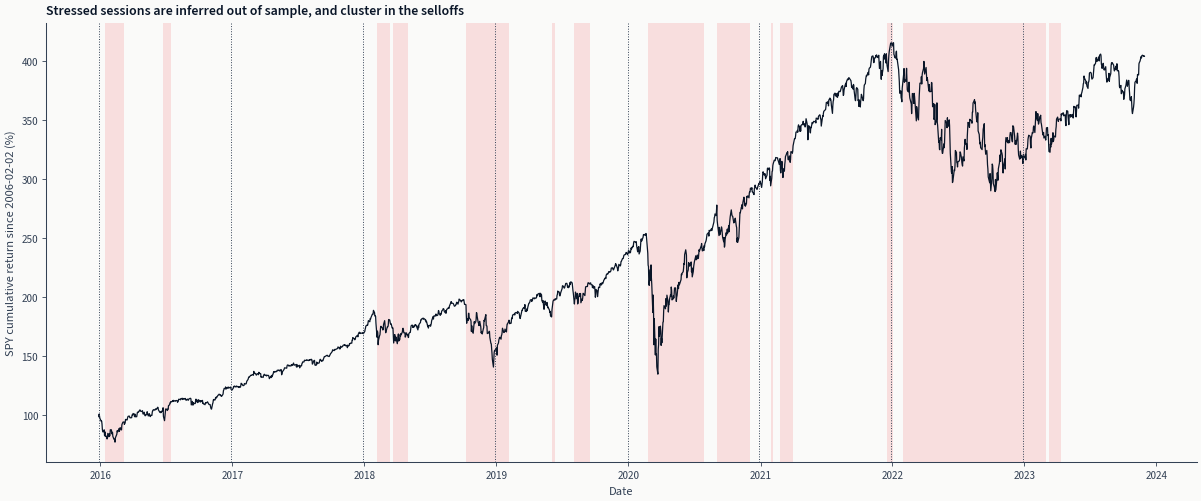

In [13]:
def in_validation_windows(column: str = "timestamp") -> pl.Expr:
    """True on a session inside any cross-validation fold's validation window."""
    predicate = pl.lit(False)
    for f in cv_splits:
        predicate = predicate | (
            (pl.col(column) >= pl.lit(f["val_start"]).cast(pl.Date))
            & (pl.col(column) <= pl.lit(f["val_end"]).cast(pl.Date))
        )
    return predicate


val_regimes = (
    hmm_features.filter(in_validation_windows())
    .drop_nulls(subset=["regime_prob_stress"])
    .sort("timestamp")
)

market_cum = market.with_columns(cum_ret=(pl.col("close") / pl.col("close").first() - 1) * 100)
market_val = market_cum.join(val_regimes.select("timestamp"), on="timestamp", how="semi").sort(
    "timestamp"
)
print(
    f"Validation sessions drawn: {len(val_regimes):,} "
    f"({val_regimes['timestamp'].min()} to {val_regimes['timestamp'].max()})"
)

fig_regime, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    market_val["timestamp"].to_numpy(),
    market_val["cum_ret"].to_numpy(),
    linewidth=0.9,
    color=COLORS["blue"],
)

_dates = val_regimes["timestamp"].to_numpy()
_stress = (val_regimes["regime_prob_stress"] > STRESS_THRESHOLD).to_numpy()
_in_run, _start = False, None
for _i in range(len(_stress)):
    if _stress[_i] and not _in_run:
        _start, _in_run = _dates[_i], True
    elif not _stress[_i] and _in_run:
        ax.axvspan(_start, _dates[_i], alpha=0.15, color=COLORS["negative"], linewidth=0)
        _in_run = False
if _in_run:
    ax.axvspan(_start, _dates[-1], alpha=0.15, color=COLORS["negative"], linewidth=0)

for f in cv_splits:
    ax.axvline(pd.Timestamp(f["val_start"]), color=COLORS["neutral"], linestyle=":", linewidth=0.7)

ax.set_xlabel("Date")
# The curve is the whole-history cumulative return sampled at validation sessions, so its
# baseline is the start of the price series rather than the left edge of the plot.
ax.set_ylabel(f"SPY cumulative return since {market_cum['timestamp'].min()} (%)")
ax.set_title(
    "Stressed sessions are inferred out of sample, and cluster in the selloffs",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
show_with_alt(
    fig_regime,
    "SPY cumulative return from 2016 to 2024 as a dark line rising steeply, with vertical pink "
    "bands marking the sessions the regime model calls stressed. The bands sit on the drawdowns "
    "- early 2016, early 2018, late 2018, the February 2020 crash and most of 2022 - and are "
    "absent from the steady climbs between.",
)

### C.2 Fractional differencing

A price series is not stationary: its mean wanders, so a model fitted on one stretch of it
describes a different distribution from the one that generated the next stretch. The usual
repair is to take returns - to difference the log price once - which is stationary but throws
away the level entirely. Everything the series remembered about where it had been is gone.

**Fractional differencing** interpolates between the two. Differencing by an order $d$ between
zero and one applies a weighted sum of all past values, with weights that decay as they reach
further back; at $d = 0$ nothing is removed and the series is the log price, at $d = 1$ it is
the log return, and in between enough of the trend is removed to make the series stable while
some of the memory is left.

The orders are fixed in advance rather than searched for. Choosing $d$ per series by testing
which value passes a stationarity test would make the transform depend on the data it is
applied to, which is the estimation channel section A described. A fixed order is purely
mechanical, so no part of it can read the future, and nothing about it needs a schedule: the
filter is applied once over each series' whole history. It is a fixed-weight causal filter,
so a value at a session is the same number whether the series it was computed over stops that
day or runs another decade. Rate-sensitive bond and credit funds get the higher order because
their log prices carry a stronger trend; the check below is what says whether that is enough.

Ten reference ETFs are transformed rather than all hundred. These series are shared across the
panel like the regime features - every ETF receives the same ten columns - and they are chosen
to span the asset classes the universe covers, so that a model has a broad-market, a
small-cap, an international, a rates, a credit, a commodity and a property series to read.

In [14]:
REFERENCE_ETFS = {
    "SPY": (0.4, "US large-cap equities"),
    "QQQ": (0.4, "US technology equities"),
    "IWM": (0.4, "US small-cap equities"),
    "EFA": (0.4, "International developed equities"),
    "EEM": (0.4, "Emerging-market equities"),
    "TLT": (0.5, "Long-dated Treasuries"),
    "GLD": (0.4, "Gold"),
    "VNQ": (0.4, "US real estate"),
    "HYG": (0.5, "High-yield credit"),
    "LQD": (0.5, "Investment-grade credit"),
}

display(
    pl.DataFrame(
        [
            {"symbol": s, "differencing order d": d, "asset class": what}
            for s, (d, what) in REFERENCE_ETFS.items()
        ]
    )
)

symbol,differencing order d,asset class
str,f64,str
"""SPY""",0.4,"""US large-cap equities"""
"""QQQ""",0.4,"""US technology equities"""
"""IWM""",0.4,"""US small-cap equities"""
"""EFA""",0.4,"""International developed equiti…"
"""EEM""",0.4,"""Emerging-market equities"""
"""TLT""",0.5,"""Long-dated Treasuries"""
"""GLD""",0.4,"""Gold"""
"""VNQ""",0.4,"""US real estate"""
"""HYG""",0.5,"""High-yield credit"""


In [15]:
ffd_features = None
for symbol, (d, _) in REFERENCE_ETFS.items():
    etf = prices.filter(pl.col("symbol") == symbol).sort("timestamp").select(["timestamp", "close"])
    if etf.height == 0:
        print(f"  {symbol}: not in the price panel, no differenced series emitted")
        continue
    series = pl.DataFrame(
        {"timestamp": etf["timestamp"], f"ffd_{symbol.lower()}": ffdiff(etf["close"].log(), d=d)}
    )
    ffd_features = (
        series
        if ffd_features is None
        else ffd_features.join(series, on="timestamp", how="full", coalesce=True)
    )

ffd_features = ffd_features.sort("timestamp")
ffd_cols = [c for c in ffd_features.columns if c.startswith("ffd_")]
print(
    f"Fractionally differenced series: {len(ffd_cols)} over {ffd_features.height:,} sessions, "
    "each computed once over its own whole history."
)
display(
    pl.DataFrame(
        [
            {
                "series": col,
                "first value": ffd_features.filter(pl.col(col).is_not_null())["timestamp"].min(),
                "sessions with a value": int(ffd_features[col].drop_nulls().len()),
            }
            for col in ffd_cols
        ]
    )
)

Fractionally differenced series: 10 over 5,031 sessions, each computed once over its own whole history.


series,first value,sessions with a value
str,date,i64
"""ffd_spy""",2006-01-03,5031
"""ffd_qqq""",2006-01-03,5031
"""ffd_iwm""",2006-01-03,5031
"""ffd_efa""",2006-01-03,5031
"""ffd_eem""",2006-01-03,5031
"""ffd_tlt""",2006-01-03,5031
"""ffd_gld""",2006-01-03,5031
"""ffd_vnq""",2006-01-03,5031
"""ffd_hyg""",2007-04-11,4713


### Did the chosen orders reach stationarity?

The claim that these orders leave a usable series is testable, so it is tested rather than
asserted. The augmented Dickey-Fuller test asks whether a series has a unit root - whether it
wanders without returning - and a small p-value is evidence that it does not. The comparison
that matters is against the untransformed log price, which should fail the test comprehensively.

The test runs on the development history only. Reading the holdout to decide whether a
transform works is the use the holdout is held back from, even for a transform that fits
nothing.

In [16]:
adf_rows = []
for symbol, (d, _) in REFERENCE_ETFS.items():
    raw = (
        prices.filter(
            (pl.col("symbol") == symbol)
            & (pl.col("timestamp") < pl.lit(HOLDOUT_START).cast(pl.Date))
        )
        .sort("timestamp")["close"]
        .log()
        .to_numpy()
    )
    if not len(raw):
        continue
    differenced = (
        ffd_features.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).cast(pl.Date))[
            f"ffd_{symbol.lower()}"
        ]
        .drop_nulls()
        .to_numpy()
    )
    adf_rows.append(
        {
            "symbol": symbol,
            "d": d,
            "log price p-value": float(adfuller(raw, autolag="AIC")[1]),
            "differenced p-value": float(adfuller(differenced, autolag="AIC")[1]),
        }
    )

adf_table = pl.DataFrame(adf_rows)
display(adf_table)
print(
    f"Series whose log price is judged stationary at 5%: "
    f"{int((adf_table['log price p-value'] < 0.05).sum())} of {adf_table.height}. "
    f"After differencing: {int((adf_table['differenced p-value'] < 0.05).sum())}."
)

symbol,d,log price p-value,differenced p-value
str,f64,f64,f64
"""SPY""",0.4,0.973684,3.2707e-18
"""QQQ""",0.4,0.978578,8.1794e-18
"""IWM""",0.4,0.841016,5.6438e-17
"""EFA""",0.4,0.605045,2.5825e-15
"""EEM""",0.4,0.096591,1.6033e-12
"""TLT""",0.5,0.394199,1.7561e-18
"""GLD""",0.4,0.180186,9.3831e-22
"""VNQ""",0.4,0.734767,4.2320e-12
"""HYG""",0.5,0.793152,2.0324e-19


Series whose log price is judged stationary at 5%: 0 of 10. After differencing: 10.


### C.3 Conditional volatility from a GARCH(1,1) model

**GARCH(1,1)** models the variance of a return series as evolving rather than fixed: each
session's variance is a weighted blend of a long-run level, the previous session's squared
surprise, and the previous session's variance. The two weights are what get estimated, and the
sum of them says how persistent volatility is - the closer to one, the longer a shock takes to
decay out of the forecast.

Unlike the regime model this one is fitted per ETF, because volatility is exactly the property
that differs across assets on a given session. It is what gives the output table a column that
varies across the cross-section, which is what a model ranking assets needs.

The fit-then-filter pattern is what keeps each value causal, and the schedule is what makes
that true at every position rather than only after a fold's training window. Coefficients are
estimated on the returns up to the start of a block, frozen, and the variance recursion is run
forward over that block; the next block re-estimates on everything up to *its* start. Past the
holdout boundary nothing is re-estimated and the last pre-holdout coefficients carry the rest.

An ETF pays the burn-in out of its own history, so a fund that launched recently carries no
conditional volatility for its first two years and one with less history than the burn-in
carries none at all. Those funds are named rather than counted, because a fund missing from
this feature changes what the column covers.

In [17]:
all_symbols = sorted(prices["symbol"].unique().to_list())
if MAX_SYMBOLS > 0:
    all_symbols = all_symbols[:MAX_SYMBOLS]

GARCH_KW = dict(mean="Constant", vol="GARCH", p=1, q=1, dist="Normal")


def garch_walk(payload: tuple[str, np.ndarray, int]) -> tuple[str, np.ndarray, list[dict]]:
    """One walk-forward GARCH per ETF: refit on schedule, filter forward, freeze at the holdout.

    Returns the annualized conditional volatility for every session the ETF quotes on, ``nan``
    over its burn-in, and one record per estimation so section D can measure what refitting
    moved.
    """
    symbol, returns, freeze_after = payload
    fits: list[dict] = []

    def fit(X_train: np.ndarray) -> dict[str, float]:
        result = arch_model(X_train[:, 0], **GARCH_KW).fit(disp="off", show_warning=False)
        coefficients = {
            "mu": float(result.params.get("mu", np.nan)),
            "omega": float(result.params.get("omega", np.nan)),
            "alpha": float(result.params.get("alpha[1]", np.nan)),
            "beta": float(result.params.get("beta[1]", np.nan)),
        }
        fits.append({"symbol": symbol, "fit_end": int(len(X_train)), **coefficients})
        return coefficients

    def apply(coefficients: dict[str, float], X_prefix: np.ndarray) -> np.ndarray:
        # `garch11_conditional_volatility` rather than the fitted result object's own
        # `conditional_volatility`: `arch` seeds its recursion from a backcast over whatever
        # sample it is handed, and the sample here runs to the end of the block being emitted,
        # so an emitted value would move when the block's later returns arrived. The shared
        # helper seeds from the coefficients' own implied long-run variance instead, which is
        # a function of the fit and of no observation in the array.
        #
        # The recursion runs on percent returns; restore decimal and annualize.
        sigma = garch11_conditional_volatility(X_prefix[:, 0], **coefficients)
        return sigma * np.sqrt(252) / 100

    values = walk_forward_feature(
        returns.reshape(-1, 1),
        burnin=GARCH_BURNIN_SESSIONS,
        refit_every=GARCH_REFIT_SESSIONS,
        fit=fit,
        apply=apply,
        n_features=1,
        freeze_after=freeze_after,
        # A single block that will not converge leaves that block null and the walk carries on.
        # Raising would discard an ETF's whole series over one window of returns.
        on_fit_error="skip",
    )
    return symbol, values[:, 0], fits

Each ETF is an independent walk, so they are spread across processes. Within one walk the
blocks are sequential - each refit reads everything before it - and each `arch_model` fit is
single-threaded, so parallelising anywhere else buys nothing. A fork context is named rather
than left to the default, because Python 3.14 defaults to forkserver, which re-imports the
parent module and cannot reach a function defined in a notebook kernel.

In [18]:
returns_panel = (
    prices.filter(pl.col("symbol").is_in(all_symbols))
    .sort(["symbol", "timestamp"])
    .with_columns(ret=(pl.col("close").pct_change() * 100).over("symbol"))
    .drop_nulls(subset=["ret"])
)

symbol_sessions = {
    symbol: group["timestamp"].to_list()
    for (symbol,), group in returns_panel.group_by(["symbol"], maintain_order=True)
}

payloads, too_short = [], []
for symbol in all_symbols:
    series = returns_panel.filter(pl.col("symbol") == symbol)
    if series.height <= GARCH_BURNIN_SESSIONS:
        too_short.append((symbol, series.height))
        continue
    freeze_after = int(
        series.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).cast(pl.Date)).height
    )
    payloads.append((symbol, series["ret"].to_numpy(), freeze_after))

if too_short:
    listed = ", ".join(f"{sym} ({n})" for sym, n in too_short)
    print(
        f"  no conditional volatility, under {GARCH_BURNIN_SESSIONS} sessions of returns: {listed}"
    )

workers = max(1, min(len(payloads), (os.cpu_count() or 2) - 1))
print(f"  fitting {len(payloads)} ETFs across {workers} processes", flush=True)
with ProcessPoolExecutor(
    max_workers=workers, mp_context=multiprocessing.get_context("fork")
) as pool:
    walked = list(pool.map(garch_walk, payloads))

garch_features = (
    pl.concat(
        [
            returns_panel.filter(pl.col("symbol") == symbol)
            .select(["timestamp", "symbol"])
            .with_columns(garch_cond_vol=pl.Series(values))
            for symbol, values, _ in walked
        ]
    )
    # Same `nan`-to-null conversion as the regime columns above, for the same reason.
    .with_columns(pl.col("garch_cond_vol").fill_nan(None))
    .drop_nulls(subset=["garch_cond_vol"])
)
garch_fit_df = pl.DataFrame([record for _, _, fits in walked for record in fits])
GARCH_COLS = ["garch_cond_vol"]

_blocks = sum(
    len(refit_boundaries(len(r), GARCH_BURNIN_SESSIONS, GARCH_REFIT_SESSIONS))
    for _, r, _ in payloads
)
print(
    f"Conditional volatility: {garch_features.height:,} values across "
    f"{garch_features['symbol'].n_unique()} ETFs, from {garch_fit_df.height:,} estimations over "
    f"{_blocks:,} blocks."
)

  fitting 100 ETFs across 23 processes


Conditional volatility: 420,162 values across 100 ETFs, from 17,659 estimations over 20,052 blocks.


The same two properties are asserted here, per ETF: nothing was estimated from a session
inside the holdout, and every ETF's first emitted value falls after it had paid its burn-in.

In [19]:
_freeze_by_symbol = {symbol: freeze for symbol, _, freeze in payloads}
_first_value = garch_features.group_by("symbol").agg(pl.col("timestamp").min().alias("first_value"))
_burnin_session = pl.DataFrame(
    [
        {"symbol": symbol, "burnin_ends": symbol_sessions[symbol][GARCH_BURNIN_SESSIONS - 1]}
        for symbol, _, _ in payloads
    ]
)
for symbol, group in garch_fit_df.group_by("symbol"):
    assert int(group["fit_end"].max()) <= _freeze_by_symbol[symbol[0]], (
        f"{symbol[0]}: a volatility model was estimated from {group['fit_end'].max()} sessions, "
        f"past the {_freeze_by_symbol[symbol[0]]} that precede the holdout"
    )
_coverage = _first_value.join(_burnin_session, on="symbol", how="inner")
assert (_coverage["first_value"] > _coverage["burnin_ends"]).all(), (
    "an ETF emitted a conditional volatility on or before the last session of its own burn-in"
)
print(
    f"Every volatility estimate ended before the holdout, and every ETF's first value falls "
    f"after its own {GARCH_BURNIN_SESSIONS}-session burn-in."
)

Every volatility estimate ended before the holdout, and every ETF's first value falls after its own 504-session burn-in.


### The property, tested rather than described

All of section A reduces to one claim: deleting the observations after a session does not move
that session's value. It is checked here on one ETF, by cutting its return series and walking
the shortened one, and the cut lands **inside** a block rather than on a refit boundary. That
is the part worth being careful about. A cut on a boundary leaves every retained block with
exactly the prefix it had, so the two walks agree whatever the recursion inside a block does;
only a cut inside one asks whether an emitted value moves when the rest of its own block
arrives. That is the question `arch`'s result object answers wrongly, which is why the
recursion is the shared helper's.

The shared driver carries the same check as a unit test over a synthetic series
(`tests/test_temporal.py`); doing it here as well is what says this notebook's own
configuration of it holds, on real returns.

In [20]:
_check_symbol, _check_returns, _check_freeze = payloads[0]
_boundaries = refit_boundaries(len(_check_returns), GARCH_BURNIN_SESSIONS, GARCH_REFIT_SESSIONS)
# The middle of the development history, offset off the boundary so the cut falls inside a block.
_midpoint = GARCH_BURNIN_SESSIONS + (_check_freeze - GARCH_BURNIN_SESSIONS) // 2
_cut = max(fit_end for fit_end, _ in _boundaries if fit_end <= _midpoint) + (
    GARCH_REFIT_SESSIONS // 2
)
assert _cut not in {fit_end for fit_end, _ in _boundaries}, "the cut landed on a refit boundary"
_full = next(values for symbol, values, _ in walked if symbol == _check_symbol)
_, _short, _ = garch_walk((_check_symbol, _check_returns[:_cut], _check_freeze))
np.testing.assert_allclose(_short, _full[:_cut], rtol=1e-12, equal_nan=True)
print(
    f"{_check_symbol}: deleting the {len(_check_returns) - _cut:,} sessions after "
    f"{_cut:,} moved none of the {int((~np.isnan(_short)).sum()):,} values before it."
)

ACWI: deleting the 2,233 sessions after 2,236 moved none of the 1,732 values before it.


### Figure F1: the schedule that was run

Both walks are done, so this draws what they did rather than what they were configured to do.
For each model the pale bar is the burn-in it paid before emitting anything and the dark bar is
where every entity it covers is emitting; the ticks on the regime row are the sessions its
parameters were estimated through, one per estimate that converged. The volatility model is
fitted per ETF and each ETF pays its own burn-in, so its row has a third segment between the
earliest and the latest first emission, where some ETFs are emitting and others are still in
their burn-in.

The dashed line is the holdout boundary. No tick falls to the right of it, which is the freeze:
the holdout is emitted from the last estimate made before it. The thin amber bars underneath
are the fold validation windows a later notebook selects rows by; they no longer decide which
parameters a row carries, which is what one dark bar spanning all of them says.

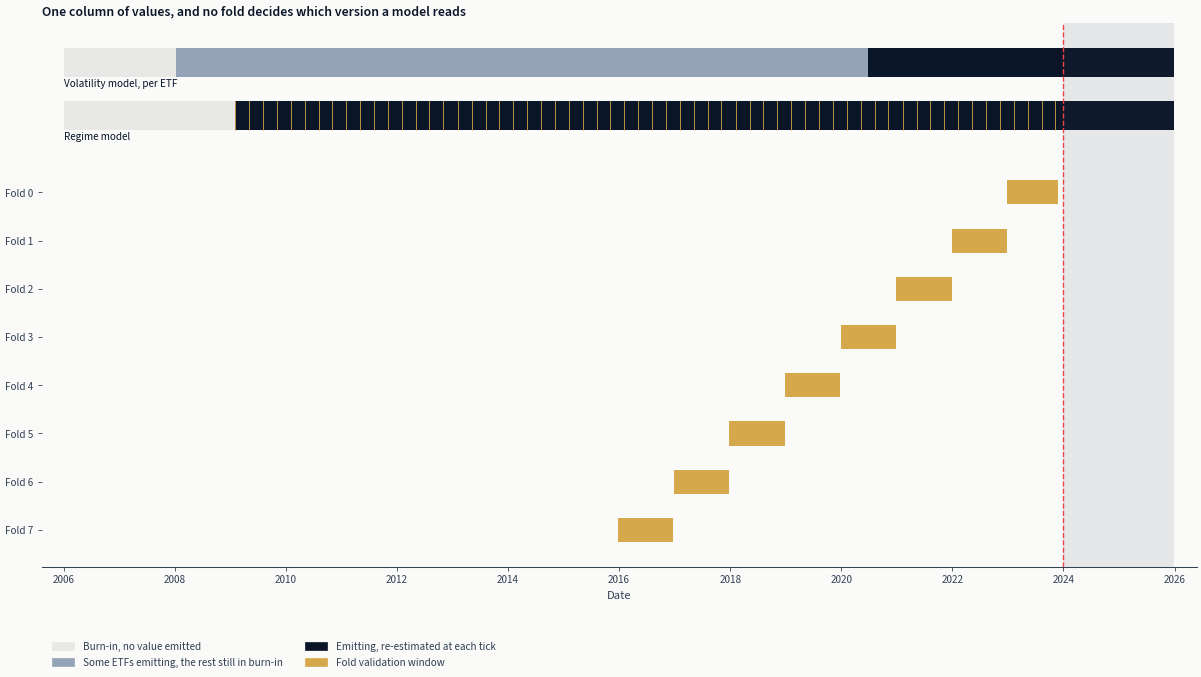

In [21]:
fig_folds, ax = plt.subplots(figsize=(12, 0.42 * len(cv_splits) + 3.4))

_holdout = pd.Timestamp(HOLDOUT_START)
_panel_start = pd.Timestamp(prices["timestamp"].min())
_panel_end = pd.Timestamp(prices["timestamp"].max())
_regime_start = pd.Timestamp(
    hmm_features.filter(pl.col("regime_prob_stress").is_not_null())["timestamp"].min()
)
# Each row is a list of (start, end, colour) segments read left to right, so the per-ETF row can
# say "none emitting", "some emitting" and "all emitting" instead of collapsing the middle into
# the burn-in it is not.
_vol_first = pd.Timestamp(_first_value["first_value"].min())
_vol_last = pd.Timestamp(_first_value["first_value"].max())
_rows = [
    (
        "Regime model",
        [
            (_panel_start, _regime_start, COLORS["silver_muted"]),
            (_regime_start, _panel_end, COLORS["blue"]),
        ],
        [pd.Timestamp(d) for d in hmm_fit_df["fit_end_session"].to_list()],
    ),
    (
        "Volatility model, per ETF",
        [
            (_panel_start, _vol_first, COLORS["silver_muted"]),
            (_vol_first, _vol_last, COLORS["recede"]),
            (_vol_last, _panel_end, COLORS["blue"]),
        ],
        [],
    ),
]
for i, (name, segments, ticks) in enumerate(_rows):
    y = -1.6 - 1.1 * i
    for seg_start, seg_end, color in segments:
        ax.barh(y, seg_end - seg_start, left=seg_start, height=0.6, color=color)
    for tick in ticks:
        ax.plot([tick, tick], [y - 0.3, y + 0.3], color=COLORS["amber"], linewidth=0.6)
    ax.text(_panel_start, y + 0.55, name, fontsize=8, color=COLORS["blue"], va="bottom")

for f in cv_splits:
    ax.barh(
        f["fold"],
        pd.Timestamp(f["val_end"]) - pd.Timestamp(f["val_start"]),
        left=pd.Timestamp(f["val_start"]),
        height=0.5,
        color=COLORS["amber"],
    )

ax.axvline(_holdout, color=COLORS["negative"], linestyle="--", linewidth=1.0)
ax.axvspan(_holdout, pd.Timestamp(HOLDOUT_END), color=COLORS["neutral"], alpha=0.10, linewidth=0)
ax.set_yticks([f["fold"] for f in cv_splits])
ax.set_yticklabels([f"Fold {f['fold']}" for f in cv_splits])
ax.invert_yaxis()
ax.set_xlabel("Date")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["silver_muted"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["recede"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["blue"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["amber"]),
]
ax.legend(
    handles,
    [
        "Burn-in, no value emitted",
        "Some ETFs emitting, the rest still in burn-in",
        "Emitting, re-estimated at each tick",
        "Fold validation window",
    ],
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.0, -0.12),
    ncol=2,
)
assert max(pd.Timestamp(d) for d in hmm_fit_df["fit_end_session"].to_list()) < _holdout, (
    "a regime estimate is dated inside the holdout, so the figure would draw a tick there"
)
_span = _panel_end - _panel_start
ax.set_xlim(_panel_start - _span * 0.02, pd.Timestamp(HOLDOUT_END) + _span * 0.02)
ax.set_title(
    "One column of values, and no fold decides which version a model reads",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine(left=True)
show_with_alt(
    fig_folds,
    "A date axis from 2006 to 2026. Two bars at the top are the two fitted models: each begins "
    "with a pale burn-in segment carrying no values, then a long dark segment. The regime row is "
    "crossed by regularly spaced amber ticks marking the sessions it was re-estimated through, "
    "and none of them falls right of the holdout. Below, eight short amber bars step back one "
    "year at a time, marking the fold validation windows a later notebook selects rows by. A "
    "dashed line and a shaded column mark the holdout.",
)

## D. What refitting moves

The schedule re-estimates both models many times over the history, on windows that grow rather
than roll, so each estimate differs from the previous one by whatever the newest block of
sessions added. Whether that is much or little is the question the cadence answers to:
parameters that barely move would say a slower schedule would have cost nothing, and
parameters that swing are a warning about any feature depending on them.

The quantity plotted is the persistence of each model, against the session its parameters were
estimated through. These are two different kinds of number and they are not comparable to each
other, which is why they are in separate panels.

In [22]:
display(
    hmm_fit_df.select(
        "fit_end_session",
        pl.col("fit_end").alias("sessions_fitted_on"),
        "mean_ret_stress",
        "mean_vol_stress",
        "mean_vol_calm",
        "persist_stress",
        "persist_calm",
    ).tail(10)
)

garch_param_summary = (
    garch_fit_df.with_columns(
        fit_end_session=pl.Series(
            [
                symbol_sessions[row["symbol"]][row["fit_end"] - 1]
                for row in garch_fit_df.iter_rows(named=True)
            ]
        ),
        persistence=pl.col("alpha") + pl.col("beta"),
    )
    .group_by("fit_end_session")
    .agg(
        pl.col("alpha").median().alias("alpha_median"),
        pl.col("beta").median().alias("beta_median"),
        pl.col("persistence").median().alias("persistence_median"),
        pl.len().alias("n_fits"),
    )
    .sort("fit_end_session")
)
display(garch_param_summary.tail(10))

fit_end_session,sessions_fitted_on,mean_ret_stress,mean_vol_stress,mean_vol_calm,persist_stress,persist_calm
date,i64,f64,f64,f64,f64,f64
2021-08-09,3906,-0.037951,27.916864,10.629064,0.982368,0.992006
2021-11-05,3969,-0.037743,27.88776,10.628277,0.982307,0.992131
2022-02-07,4032,-0.03325,27.95267,10.717173,0.98223,0.991975
2022-05-09,4095,-0.038251,27.511328,10.665799,0.982771,0.991621
2022-08-09,4158,-0.032168,27.365755,10.618732,0.983161,0.991246
2022-11-07,4221,-0.034311,26.874655,10.510148,0.983156,0.990399
2023-02-08,4284,-0.026011,26.208298,10.354024,0.983879,0.989745
2023-05-10,4347,-0.031689,27.245674,10.811362,0.984168,0.991906
2023-08-10,4410,-0.029403,27.100984,10.767209,0.983868,0.991748


fit_end_session,alpha_median,beta_median,persistence_median,n_fits
date,f64,f64,f64,u32
2023-12-12,0.080894,0.906042,0.989697,4
2023-12-13,0.076737,0.908423,0.986524,3
2023-12-14,0.145866,0.854134,1.0,3
2023-12-15,0.100409,0.887444,0.987853,1
2023-12-19,0.073588,0.917811,0.991399,1
2023-12-20,0.160971,0.810568,0.974926,4
2023-12-21,0.07252,0.922096,0.994616,1
2023-12-27,0.227604,0.772396,1.0,1
2023-12-28,0.161215,0.803806,0.973878,3


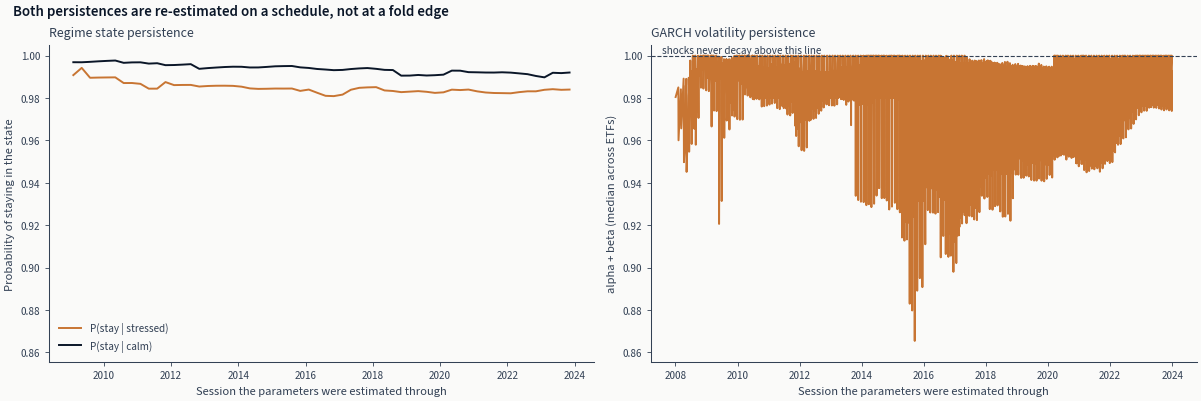

In [23]:
fig_stab, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

ax_l.plot(
    hmm_fit_df["fit_end_session"].to_numpy(),
    hmm_fit_df["persist_stress"].to_numpy(),
    color=COLORS["copper"],
    label="P(stay | stressed)",
)
ax_l.plot(
    hmm_fit_df["fit_end_session"].to_numpy(),
    hmm_fit_df["persist_calm"].to_numpy(),
    color=COLORS["blue"],
    label="P(stay | calm)",
)
ax_l.set_xlabel("Session the parameters were estimated through")
ax_l.set_ylabel("Probability of staying in the state")
ax_l.legend(frameon=False, fontsize=8)
ax_l.set_title("Regime state persistence", loc="left", fontsize=10)

ax_r.plot(
    garch_param_summary["fit_end_session"].to_numpy(),
    garch_param_summary["persistence_median"].to_numpy(),
    color=COLORS["copper"],
)
ax_r.axhline(1.0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax_r.annotate(
    "shocks never decay above this line",
    xy=(0.02, 1.0),
    xycoords=("axes fraction", "data"),
    va="bottom",
    fontsize=8,
    color=COLORS["neutral"],
)
ax_r.set_xlabel("Session the parameters were estimated through")
ax_r.set_ylabel("alpha + beta (median across ETFs)")
ax_r.set_title("GARCH volatility persistence", loc="left", fontsize=10)

# Both panels carry a probability-scale persistence, so they share limits. Letting each
# autoscale makes a flat line and a moving one look equally dramatic.
_lo = min(
    float(hmm_fit_df["persist_stress"].min()),
    float(hmm_fit_df["persist_calm"].min()),
    float(garch_param_summary["persistence_median"].min()),
)
for _ax in (ax_l, ax_r):
    _ax.set_ylim(_lo - 0.01, 1.005)

fig_stab.suptitle(
    "Both persistences are re-estimated on a schedule, not at a fold edge",
    x=0.01,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
show_with_alt(
    fig_stab,
    "Two panels against the session each estimate was made through. On the left the probability "
    "of staying in each regime state, both close to one and drifting slowly over the sixty-odd "
    "re-estimations. On the right the median GARCH persistence across ETFs, also close to one, "
    "moving more sharply around the volatile stretches of the sample and staying below the "
    "dashed line at one, above which shocks would never decay.",
)

The two persistences are both numbers close to one, and they are not the same kind of number.
A regime self-transition probability $p$ says how long a state lasts: the expected run is
$1/(1-p)$ sessions. A GARCH coefficient sum says how a variance shock decays: the fraction of
it still present after $k$ sessions is $(\alpha+\beta)^k$, so the number of sessions after
which half of it is left is $\ln(1/2)/\ln(\alpha+\beta)$. Converted to sessions they become
readable as statements about the market rather than as coefficients, and both are printed
below alongside the ranges.

What decides the refit cadence is a different quantity, and it is worth keeping the two apart.
How long a regime lasts, or how long a shock takes to decay, is what the fitted model says
about the world; a model can describe fast-moving states and still have parameters that never
need re-estimating. The cadence question is how far the parameters themselves move from one
estimate to the next, and the ranges below are that measurement.

In [24]:
def _range(series: pl.Series) -> float:
    return float(series.max() - series.min())


hmm_spread = max(_range(hmm_fit_df["persist_stress"]), _range(hmm_fit_df["persist_calm"]))
garch_spread = _range(garch_param_summary["persistence_median"])
print(f"Widest regime persistence range across estimates: {hmm_spread:.4f}")
print(f"GARCH median persistence range across estimates:  {garch_spread:.4f}")

_p_stress = hmm_fit_df["persist_stress"]
_p_calm = hmm_fit_df["persist_calm"]
_p_garch = garch_param_summary["persistence_median"]
print(
    f"Expected run in the stressed state: {1 / (1 - _p_stress.max()):.0f} sessions at the most "
    f"persistent estimate, {1 / (1 - _p_stress.min()):.0f} at the least."
)
print(
    f"Expected run in the calm state: {1 / (1 - _p_calm.max()):.0f} sessions at the most "
    f"persistent estimate, {1 / (1 - _p_calm.min()):.0f} at the least."
)
print(
    f"GARCH variance-shock half-life: {np.log(0.5) / np.log(_p_garch.max()):.0f} sessions at the "
    f"most persistent estimate, {np.log(0.5) / np.log(_p_garch.min()):.0f} at the least."
)

Widest regime persistence range across estimates: 0.0133
GARCH median persistence range across estimates:  0.1345
Expected run in the stressed state: 173 sessions at the most persistent estimate, 52 at the least.
Expected run in the calm state: 431 sessions at the most persistent estimate, 98 at the least.
GARCH variance-shock half-life: -62450858 sessions at the most persistent estimate, 5 at the least.


The two tables above are the measurement the cadence answers to. The regime model's
self-transition probabilities move across the re-estimations by the range printed under the
figure, and the median GARCH persistence by its own; both stay below one, so a variance shock
in this sample always decays. Read as descriptions of the market rather than as coefficients,
the same fits put the expected run of each regime and the half-life of a variance shock at the
session counts printed above.

What the ranges do not settle is whether a slower schedule would have been safe. That is a
question about the estimates a slower schedule would have produced, and this notebook computes
only the ones it was configured for.

## E. Combine and emit

The regime and differenced-price features are one value per session, shared by every ETF; the
conditional volatility is one value per ETF per session. They are combined onto a panel keyed
by session and symbol, and that is the whole key: with the schedule bounding every estimate,
a session's value is the same number whichever fold a later notebook reads it under, so there
is nothing for a fold tag to distinguish. Chapter 11 joins this table on the key alone.

Three things are checked before anything is written. The key is unique, so no downstream join
can multiply rows. Every session-and-symbol the price panel offers is in the output, so no row
was lost on the way through the joins. And the column set is exactly what Chapter 11 expects
to read.

In [25]:
skeleton = prices.select(["timestamp", "symbol"]).unique()
date_level = hmm_features.join(ffd_features, on="timestamp", how="full", coalesce=True)
model_based = (
    skeleton.join(date_level, on="timestamp", how="left")
    .join(garch_features, on=["timestamp", "symbol"], how="left")
    .sort(["timestamp", "symbol"])
)
KEY_COLS = ["timestamp", "symbol"]
FEATURE_COLS = [c for c in model_based.columns if c not in KEY_COLS]

In [26]:
assert model_based.select(KEY_COLS).is_duplicated().sum() == 0, (
    "the panel key repeats; a downstream join would multiply rows"
)
assert model_based.height == skeleton.height, (
    f"emitted {model_based.height:,} rows against {skeleton.height:,} session-symbol pairs in "
    "the price panel"
)
assert "fold" not in model_based.columns, (
    "a fold column reached the panel; the schedule is what bounds an estimate here"
)
EXPECTED_COLUMNS = [
    "timestamp",
    "symbol",
    "regime_prob_stress",
    "regime_transition",
    "regime_log_duration",
    *[f"ffd_{s.lower()}" for s in REFERENCE_ETFS],
    "garch_cond_vol",
]
assert sorted(model_based.columns) == sorted(EXPECTED_COLUMNS), (
    f"column set changed: {sorted(set(model_based.columns) ^ set(EXPECTED_COLUMNS))}"
)
print(
    f"{model_based.height:,} rows, {len(FEATURE_COLS)} features, "
    f"{model_based['symbol'].n_unique()} ETFs, one row per session-symbol."
)

470,662 rows, 14 features, 100 ETFs, one row per session-symbol.


### What the burn-in costs

A model-based feature legitimately starts after the estimation window that produced it, so the
leading gap is reported rather than asserted away. It is reported here because it used to be
invisible: `sequence_dataset` turns a null feature into `0.0`, which after normalization is the
feature's mean, so rows missing a feature were fitted as average observations and nothing
raised. The same geometry goes into the digest sidecar, so a later stage can compare against
it instead of measuring it again by hand.

The distribution summaries beside the coverage are restricted to the development history: a
mean and a spread are a description of what the features look like, and that description is
not something to form expectations from while the holdout is still held back.

In [27]:
_dev = model_based.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).cast(pl.Date))
display(
    pl.DataFrame(
        [
            {
                "feature": col,
                "first value": model_based.filter(pl.col(col).is_not_null())["timestamp"].min(),
                "rows with a value": model_based[col].drop_nulls().len(),
                "coverage": model_based[col].drop_nulls().len() / model_based.height,
                "mean (development)": _dev[col].drop_nulls().mean(),
                "std (development)": _dev[col].drop_nulls().std(),
            }
            for col in FEATURE_COLS
        ]
    )
)
_covered = model_based.filter(in_validation_windows())
print(
    "Coverage over the sessions the folds validate on, which is what a model actually reads: "
    + ", ".join(
        f"{col} {_covered[col].drop_nulls().len() / _covered.height:.1%}" for col in FEATURE_COLS
    )
)

feature,first value,rows with a value,coverage,mean (development),std (development)
str,date,i64,f64,f64,f64
"""regime_prob_stress""",2009-02-04,411285,0.873844,0.259508,0.427855
"""regime_transition""",2009-02-04,411285,0.873844,0.01467,0.072386
"""regime_log_duration""",2009-02-04,411285,0.873844,4.420407,1.410809
"""ffd_spy""",2006-01-03,470662,1.0,0.226711,0.10167
"""ffd_qqq""",2006-01-03,470662,1.0,0.207464,0.081344
…,…,…,…,…,…
"""ffd_gld""",2006-01-03,470662,1.0,0.208191,0.092144
"""ffd_vnq""",2006-01-03,470662,1.0,0.167808,0.079659
"""ffd_hyg""",2007-04-11,449008,0.953992,0.0867,0.070732


Coverage over the sessions the folds validate on, which is what a model actually reads: regime_prob_stress 100.0%, regime_transition 100.0%, regime_log_duration 100.0%, ffd_spy 100.0%, ffd_qqq 100.0%, ffd_iwm 100.0%, ffd_efa 100.0%, ffd_eem 100.0%, ffd_tlt 100.0%, ffd_gld 100.0%, ffd_vnq 100.0%, ffd_hyg 100.0%, ffd_lqd 100.0%, garch_cond_vol 99.5%


The table is written with a digest sidecar beside it: a short string computed from the values,
so that two files holding the same numbers get the same string and any changed number gets a
different one. It records the digests of the inputs too, which is what turns it into a chain -
a later stage can see not only that the feature values changed but that they changed because
something upstream did. The price panel is the only input: nothing here reads a label, because
nothing here is bounded by a fold any more.

In [28]:
record = write_model_based(
    model_based,
    FEATURES_DIR / "model_based.parquet",
    keys=KEY_COLS,
    feature_columns=FEATURE_COLS,
    time_column="timestamp",
    fold_column=None,
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={"load_etfs": value_digest(prices)},
    metadata={
        "hmm": {
            "burnin": HMM_BURNIN_SESSIONS,
            "refit_every": HMM_REFIT_SESSIONS,
            "n_states": STATE_COUNT,
            "n_restarts": N_RESTARTS,
            "n_estimations": hmm_fit_df.height,
        },
        "garch": {
            "burnin": GARCH_BURNIN_SESSIONS,
            "refit_every": GARCH_REFIT_SESSIONS,
            "n_estimations": garch_fit_df.height,
            "n_symbols": int(garch_features["symbol"].n_unique()),
        },
        "freeze_after": HOLDOUT_START,
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'model_based.parquet')}")
print(f"  digest {record['digest']}, {record['n_rows']:,} rows")

Wrote case_studies/etfs/features/model_based.parquet
  digest f74f1159a3c9cd2d, 470,662 rows


## F. Incremental evaluation

The last question is whether these features order the cross-section of forward returns at all.
The **information coefficient** is the rank correlation between a feature and the return that
follows, computed across the assets scored on one session and then averaged over sessions. It
is a screen and not a decision: nothing here drops a feature, and the comparison against the
stage-03 arithmetic features is made in [`05_evaluation`](05_evaluation.ipynb).

Only the sessions the folds validate on are scored. Training sessions would be measuring how
well a model describes what it was fitted on, and the holdout is excluded because reading it
here is the use it is held back from.

In [29]:
val_features = model_based.filter(in_validation_windows())

scored = val_features.join(labels, on=["timestamp", "symbol"], how="inner").drop_nulls(
    subset=[PRIMARY_LABEL]
)
# An inner join can lose rows in either direction; say how many and why rather than let it pass.
print(
    f"{val_features.height:,} validation rows, of which {scored.height:,} carry a resolved "
    f"{PRIMARY_LABEL}; {val_features.height - scored.height:,} do not, being the sessions whose "
    "forward window runs past the end of the price history or whose ETF was not yet quoting."
)
print(
    f"{scored['symbol'].n_unique()} ETFs scored across {scored['timestamp'].n_unique():,} sessions."
)

198,877 validation rows, of which 198,877 carry a resolved fwd_ret_21d; 0 do not, being the sessions whose forward window runs past the end of the price history or whose ETF was not yet quoting.
100 ETFs scored across 1,995 sessions.


The conditional volatility differs across ETFs on a session, so its information coefficient is
a genuine cross-sectional rank correlation. The regime and differenced-price features do not -
every ETF carries the same value on a session - so a cross-sectional correlation on them is
zero by construction, and they are measured instead as a time-series correlation against the
average forward return of the panel. That is a statement about timing the market rather than
about ranking within it, and the two numbers are not comparable to each other.

Both need a standard error that accounts for overlapping observations. Consecutive sessions share
most of their forward window, so treating them as independent would overstate the evidence by
a wide margin. The cross-sectional series is corrected with a heteroskedasticity- and
autocorrelation-consistent estimator, given the label horizon as its lag; the time-series ones
use a stationary bootstrap, which resamples blocks rather than points so that the dependence
inside a block is preserved.

The bootstrap draws its blocks from NumPy's global random stream, so it is seeded immediately
before the loop. Without that the p-values move a little on every execution, and the count of
features the multiplicity correction retains moves with them, on identical coefficients.

In [30]:
DATE_LEVEL_COLS = [c for c in FEATURE_COLS if c not in GARCH_COLS]
feature_stats = {}

for feat in GARCH_COLS:
    rankable = scored.filter(pl.col(feat).is_not_null())
    ic_series = cross_sectional_ic_series(
        rankable,
        rankable,
        pred_col=feat,
        ret_col=PRIMARY_LABEL,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    )
    # A session below the floor comes back as a row with a null coefficient rather than as no
    # row at all, so the guard has to count coefficients and not rows - otherwise a universe
    # too narrow to rank would still reach the correction below, as an all-null series.
    ic_series = ic_series.filter(pl.col("ic").is_not_null() & pl.col("ic").is_finite())
    print(f"{feat}: {ic_series.height:,} sessions carry a cross-sectional coefficient")
    if ic_series.height < MIN_IC_SESSIONS:
        print(f"  fewer than {MIN_IC_SESSIONS}; not enough to correct for serial dependence")
        continue
    stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_DAYS)
    feature_stats[feat] = {
        "ic": stats["mean_ic"],
        "t_stat": stats["t_stat"],
        "p_value": stats["p_value"],
        "se": stats["hac_se"],
    }

garch_cond_vol: 1,995 sessions carry a cross-sectional coefficient


In [31]:
panel_return = (
    scored.group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).mean().alias("panel_ret"))
    .sort("timestamp")
)
# One row per session by construction now - the panel carries one value per session, not one per
# session and fold - so the deduplication is a guard rather than a choice.
date_series = (
    val_features.select(["timestamp", *DATE_LEVEL_COLS])
    .unique(subset=["timestamp"], keep="first")
    .sort("timestamp")
    .join(panel_return, on="timestamp", how="inner")
    .drop_nulls()
)

np.random.seed(SEED)
for feat in DATE_LEVEL_COLS:
    x = date_series[feat].to_numpy()
    y = date_series["panel_ret"].to_numpy()
    keep = ~(np.isnan(x) | np.isnan(y))
    if keep.sum() < MIN_IC_SESSIONS:
        continue
    result = robust_ic(x[keep], y[keep], return_details=True)
    feature_stats[feat] = {
        "ic": result["ic"],
        "t_stat": result.get("t_stat", 0.0),
        "p_value": result.get("p_value"),
        "se": result.get("bootstrap_std", result.get("bootstrap_se", 0.0)),
    }

Every feature above was screened against the same label on the same sessions, so reading the
p-values one at a time would find something significant sooner or later whatever the features
were worth. The Benjamini-Hochberg procedure adjusts the whole set at once, controlling the
share of the retained features expected to be false rather than the chance of any single false
positive.

In [32]:
evaluation = pl.DataFrame(
    [
        {
            "feature": feat,
            "kind": "cross-sectional" if feat in GARCH_COLS else "time-series",
            "ic": s["ic"],
            "t_stat": s["t_stat"],
            "p_value": s["p_value"],
            "se": s["se"],
        }
        for feat, s in feature_stats.items()
    ]
).sort("ic", descending=True)

_p = evaluation["p_value"].to_list()
if evaluation.height and all(v is not None for v in _p):
    _fdr = benjamini_hochberg_fdr(_p, alpha=0.05, return_details=True)
    evaluation = evaluation.with_columns(retained=pl.Series(_fdr["rejected"].tolist()))
else:
    evaluation = evaluation.with_columns(retained=pl.lit(False, dtype=pl.Boolean))
n_retained = int(evaluation.filter(pl.col("retained")).height)

display(evaluation)
print(f"Retained by Benjamini-Hochberg at 5%: {n_retained} of {evaluation.height}")

feature,kind,ic,t_stat,p_value,se,retained
str,str,f64,f64,f64,f64,bool
"""ffd_tlt""","""time-series""",0.189477,2.371211,0.002,0.079907,true
"""regime_prob_stress""","""time-series""",0.171462,2.14165,0.023,0.080061,true
"""ffd_lqd""","""time-series""",0.139792,1.735038,0.033,0.08057,false
"""ffd_gld""","""time-series""",0.069414,0.836257,0.295,0.083005,false
"""garch_cond_vol""","""cross-sectional""",0.068999,2.519155,0.011841,0.02739,true
…,…,…,…,…,…,…
"""ffd_qqq""","""time-series""",-0.142454,-1.791099,0.041,0.079534,false
"""ffd_vnq""","""time-series""",-0.17798,-2.442207,0.003,0.072877,true
"""ffd_efa""","""time-series""",-0.182395,-2.464351,0.009,0.074014,true


Retained by Benjamini-Hochberg at 5%: 7 of 14


The bars carry no interval, because the two kinds of coefficient are estimated with different
machinery and a shared error bar would invite a comparison the numbers do not support. The
standard errors are in the table above, and the `kind` column says which is which.

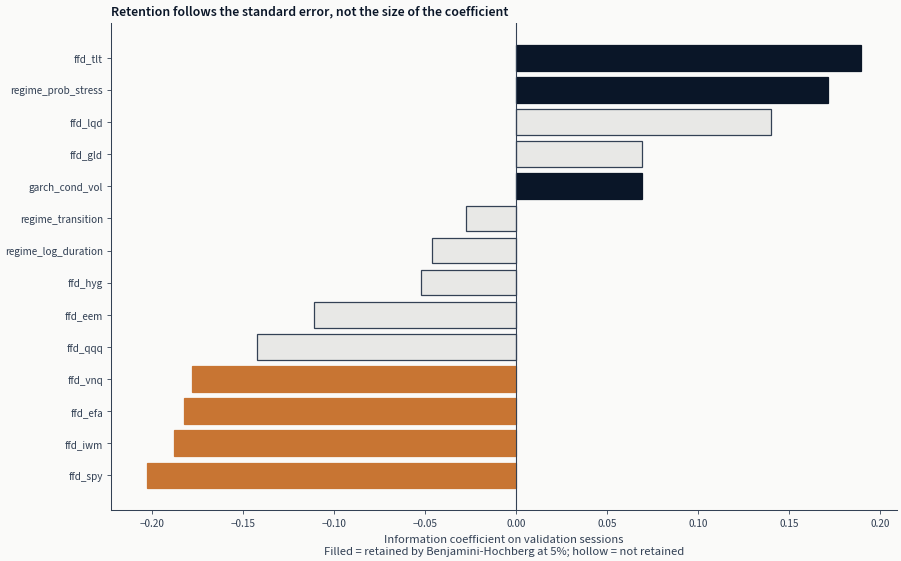

In [33]:
ordered = evaluation.sort("ic")
bar_fill = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["retained"]
    else COLORS["silver_muted"]
    for row in ordered.to_dicts()
]
bar_edge = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["retained"]
    else COLORS["neutral"]
    for row in ordered.to_dicts()
]

fig_ic, ax = plt.subplots(figsize=(9, max(3.0, 0.4 * ordered.height)))
ax.barh(
    ordered["feature"].to_list(),
    ordered["ic"].to_numpy(),
    color=bar_fill,
    edgecolor=bar_edge,
    linewidth=0.9,
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel(
    "Information coefficient on validation sessions\n"
    "Filled = retained by Benjamini-Hochberg at 5%; hollow = not retained"
)
ax.set_title(
    "Retention follows the standard error, not the size of the coefficient",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
show_with_alt(
    fig_ic,
    "Fourteen horizontal bars of information coefficient on validation sessions, sorted from "
    "the largest positive at the top to the largest negative at the bottom. Filled bars are "
    "retained by Benjamini-Hochberg at 5 percent and hollow ones are not, and the two do not "
    "follow the ordering: hollow bars sit above filled ones of the same size.",
)

The screen runs on the validation rows counted above, and the table beside the figure is what
it produced: a coefficient, a standard error appropriate to how it was estimated, and whether
Benjamini-Hochberg retains it at 5%. Magnitude is not what decides retention - the
cross-sectional coefficient is estimated across a hundred ETFs on every session and carries a
much smaller standard error than a date-level one estimated on one series - so the filled and
hollow bars do not follow the ordering.

The screen is univariate and it is a screen. Nothing is dropped here, and what these features
add on top of the stage-03 arithmetic ones is measured in
[`05_evaluation`](05_evaluation.ipynb).

## Key takeaways

- **Fit on a schedule, not inside a fold.** A fold model is estimated on the fold's whole
  training window and then run forward from the start of it, so its earliest training rows
  carry parameters estimated from years of their own future. A refit schedule - burn-in, fit,
  emit to the next refit, refit on everything up to that point - has no position in the history
  where that is true.
- **A schedule replaces the fold as the thing that bounds an estimate.** Once no fold decides
  which parameters a row carries, the artifact needs no fold column: one value per asset per
  session, the same value whichever fold reads it, and no way for two labels with different
  fold geometry to disagree about what a session's feature is.
- **Freeze at the holdout rather than stopping there.** The holdout still needs feature values
  or the final notebook has nothing to score. It gets them from its own returns run through
  the last coefficients estimated before it, so data inside the holdout conditions the value
  and no data inside it estimated a parameter.
- **Filtered, never smoothed.** Given fixed parameters there is usually more than one way to
  run a model over a series, and the more accurate one generally reads the whole series. Look
  for the method that conditions on the past alone; if the library's convenient default is the
  other one, that default is a look-ahead.
- **Fix what you can rather than estimating it.** The differencing orders are chosen in advance
  so that no part of the transform reads the data, which removes an entire leak channel instead
  of scheduling around it. Where a choice is fixed rather than fitted, test that it was a
  workable choice - here with a stationarity test whose result is shown rather than asserted.
- **Test the property, do not describe it.** All of this reduces to one claim: deleting the
  observations after a session does not move that session's value. Section C.3 cuts a series
  and re-walks it to check exactly that, because a notebook that merely asserts causality in
  prose runs clean while leaking.
- **Report the burn-in.** A fitted feature starts late, and a null feature is silently filled
  with the feature's mean several stages downstream. The first valid session of every column
  goes in the output table and in the digest sidecar.

### Known limitations

- **The regime feature is the same number for every ETF on a session.** It can only help a
  model that ranks assets by interacting with something that does vary across them; on its own
  it carries no cross-sectional information at all, and its coefficient here is measured
  against the panel average rather than against the cross-section.
- **The estimation windows expand rather than roll.** Every refit sees the whole history, so a
  structural break stays in the estimate for good rather than ageing out of it. A rolling
  window is the alternative and the driver supports it; which is right is an empirical
  question about this market that this notebook does not answer.
- **A late-listing ETF carries no conditional volatility for its first two years.** The burn-in
  is paid out of each fund's own history and cannot be paid earlier, so the panel's coverage of
  this feature grows through the sample. The table in section E is where that shows up.
- **The holdout's parameters are older than every other session's.** Everything before the
  holdout is described by coefficients estimated at most one refit interval earlier; the
  holdout is described by the last pre-holdout estimate throughout, so its coefficients age
  across the window. That is the price of not estimating anything on sealed data.
- **Ten reference series stand in for the asset classes in the panel.** They were chosen to
  span the universe rather than derived from it, and a different ten would give a model
  different columns to read.
- **The evaluation is univariate.** Each feature is screened alone, so it says nothing about
  what any of them add on top of each other or on top of the arithmetic features from stage 03.
  That comparison is the subject of [`05_evaluation`](05_evaluation.ipynb).